# NICHES

In [2]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(scales)
library(NICHES)
library(stringr)
library(reshape2)
library(cowplot)

In [3]:
options(warn=-1)

In [4]:
getwd()

[1] "/Users/pandavis/Desktop/lab_directory/pvat_8w_24w_data/codebase/niches_cci/System2Cell"

In [5]:
male_8weeks_rds <- readRDS('../combined_male_8weeks.rds')

In [6]:
data.list <- SplitObject(male_8weeks_rds, split.by="sample_type")

In [7]:
data.list[1]
data.list[2]

$taPVAT_Control_8W_M
An object of class Seurat 
20743 features across 5843 samples within 1 assay 
Active assay: RNA (20743 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap


$taPVAT_HF_8W_M
An object of class Seurat 
20743 features across 9608 samples within 1 assay 
Active assay: RNA (20743 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap


In [8]:
table(data.list[[1]]@meta.data['celltype_broad'])
table(data.list[[2]]@meta.data['celltype_broad'])

celltype_broad
       Adipocytes Endothelial_Cells       Fibroblasts      Immune_Cells 
             3547               588               788               413 
Mesothelial_Cells    Neuronal_Cells         Pericytes              SMCs 
              212                 4               288                 3 

celltype_broad
       Adipocytes Endothelial_Cells       Fibroblasts      Immune_Cells 
             6429               876              1077               577 
Mesothelial_Cells    Neuronal_Cells         Pericytes              SMCs 
              193                22               426                 8 

In [9]:
max.cells <- min(ncol(data.list[[1]]),ncol(data.list[[2]])) 

for (i in 1:length(data.list)){
  Idents(data.list[[i]]) <- data.list[[i]]$sample_type
  data.list[[i]] <- subset(data.list[[i]],cells = WhichCells(data.list[[i]],downsample = max.cells))
  Idents(data.list[[i]]) <- data.list[[i]]$celltype_broad
}


In [10]:
max.cells

[1] 5843

In [11]:
distribution <- data.frame(CTRL = table(Idents(data.list[[1]])),
                            HF = table(Idents(data.list[[2]])))
distribution <- reshape2::melt(distribution)

Using CTRL.Var1, HF.Var1 as id variables



In [12]:
distribution

CTRL.Var1,HF.Var1,variable,value
<fct>,<fct>,<fct>,<int>
Fibroblasts,Adipocytes,CTRL.Freq,788
Adipocytes,Endothelial_Cells,CTRL.Freq,3547
Immune_Cells,Fibroblasts,CTRL.Freq,413
Endothelial_Cells,Immune_Cells,CTRL.Freq,588
Pericytes,Mesothelial_Cells,CTRL.Freq,288
Mesothelial_Cells,Pericytes,CTRL.Freq,212
Neuronal_Cells,SMCs,CTRL.Freq,4
SMCs,Neuronal_Cells,CTRL.Freq,3
Fibroblasts,Adipocytes,HF.Freq,3917


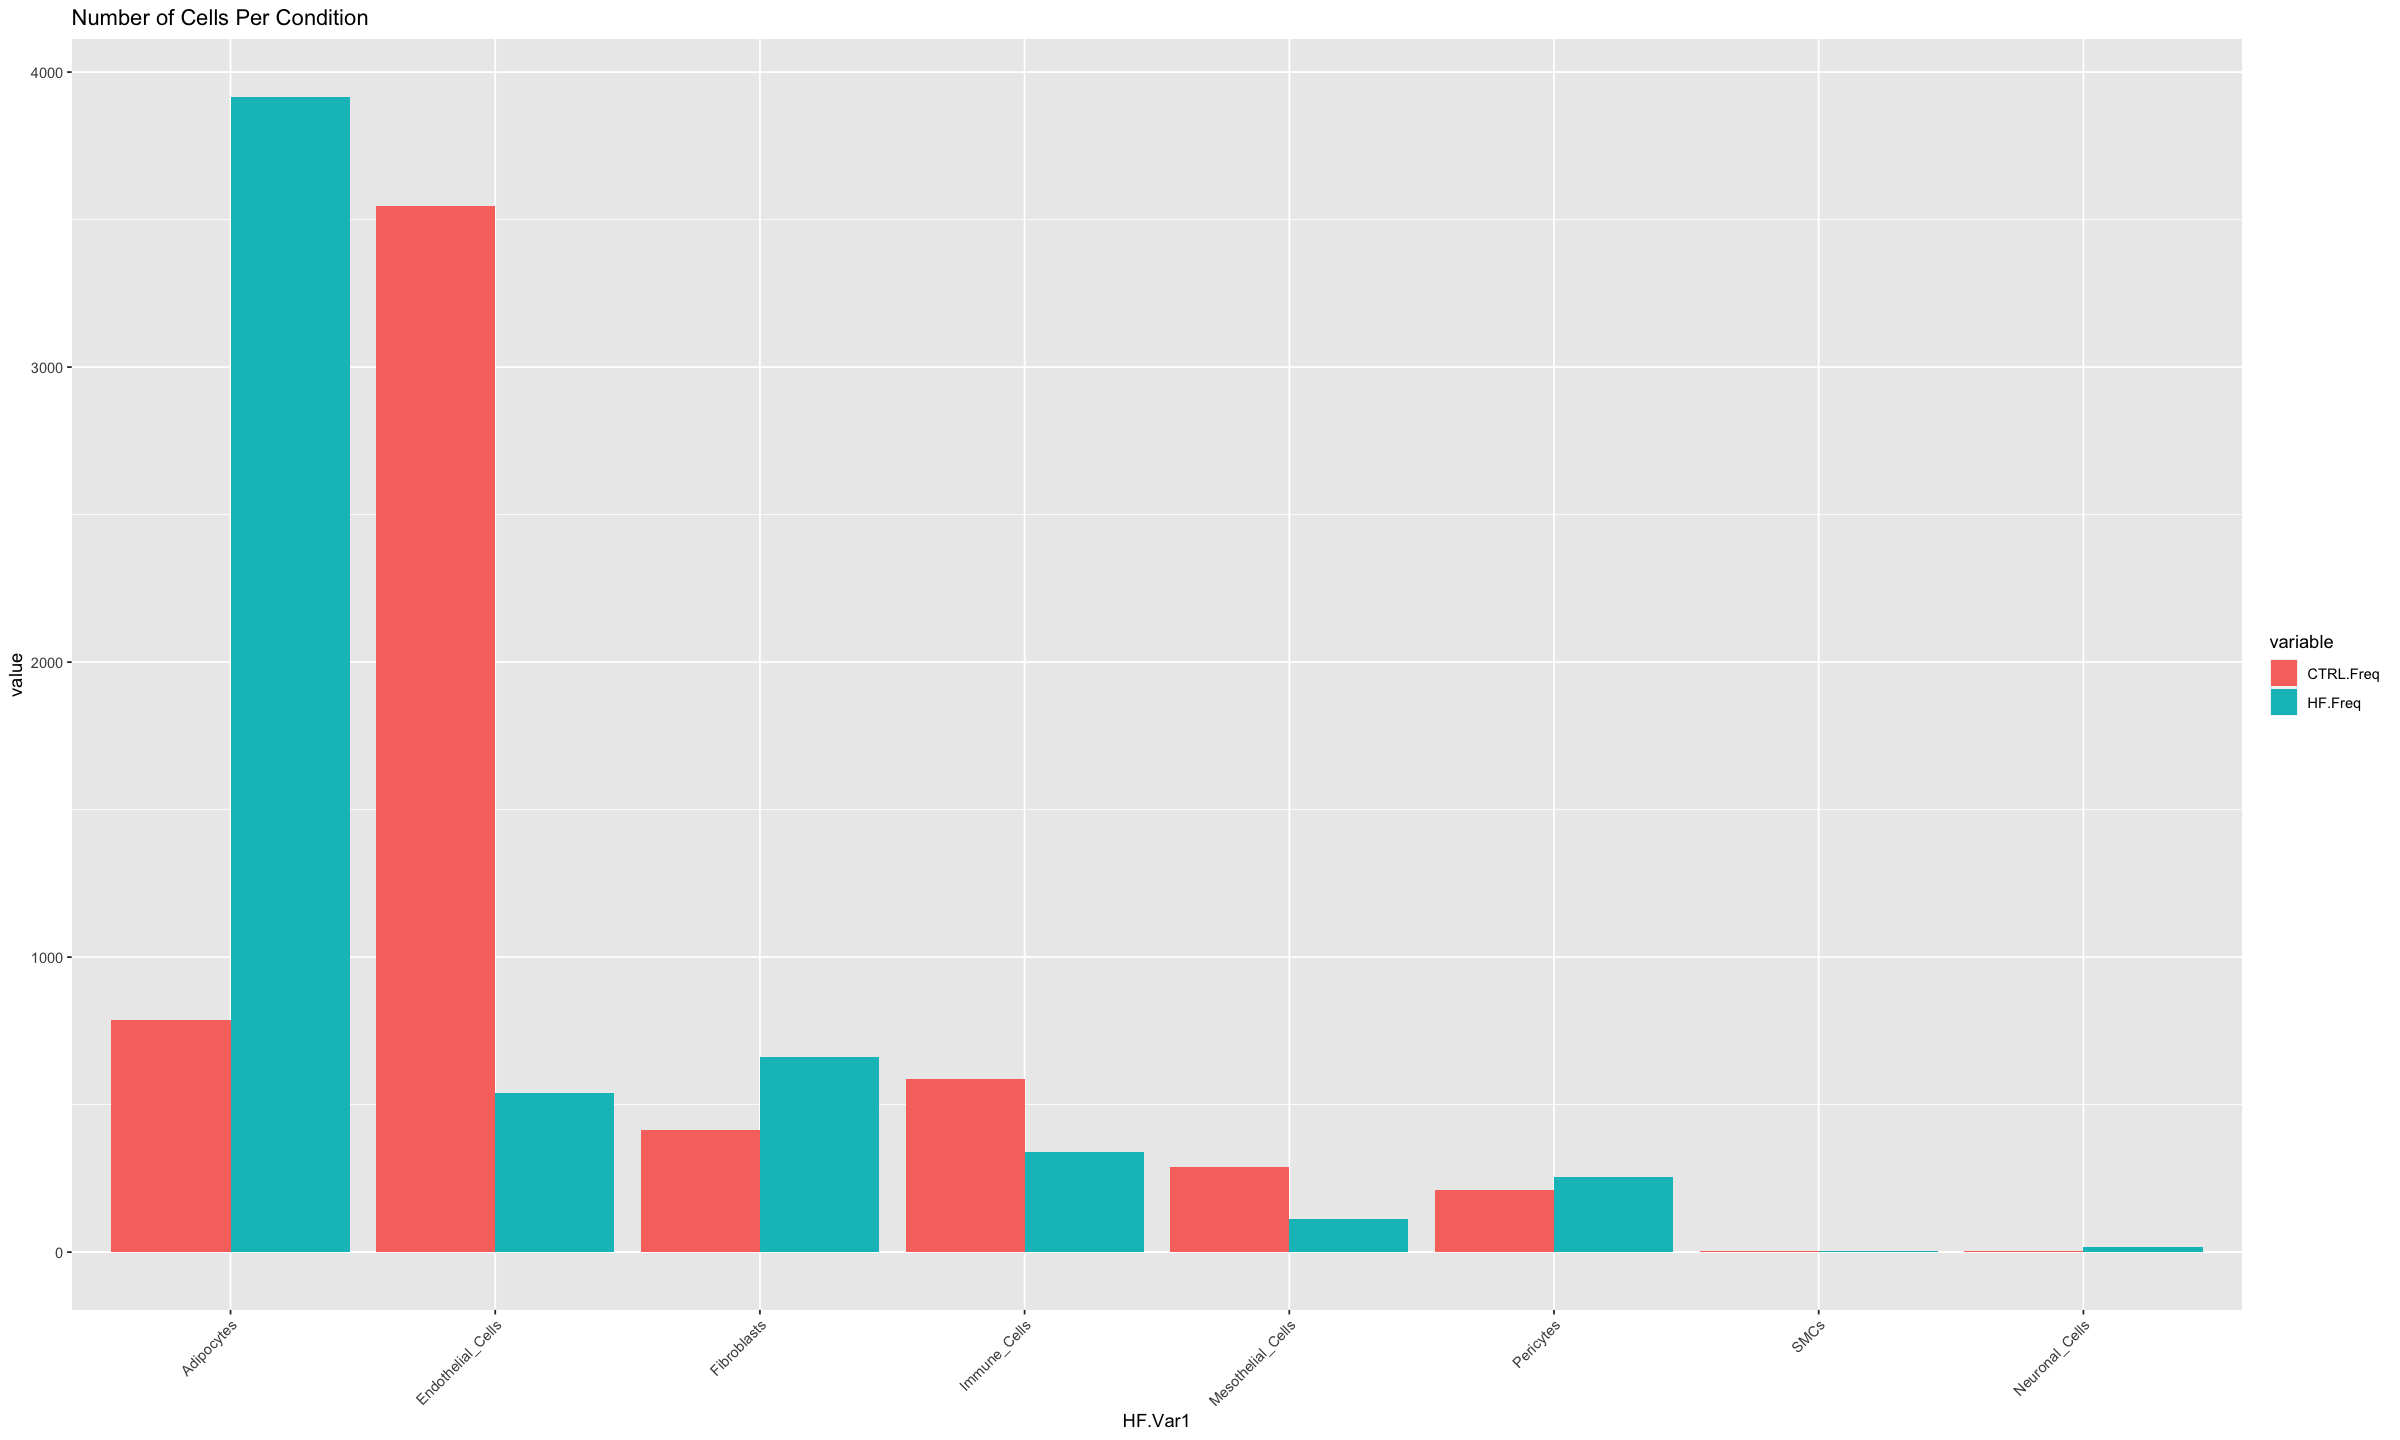

In [13]:
options(repr.plot.width=20, repr.plot.height=12)

ggplot(data = distribution,aes(x = HF.Var1,y=value,fill = variable))+geom_bar(stat='identity',position='dodge')+
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+
  ggtitle('Number of Cells Per Condition')

In [14]:
ncol(data.list[[1]])==ncol(data.list[[2]])

[1] TRUE

In [15]:
table(data.list[[1]]@meta.data['celltype_broad'])
table(data.list[[2]]@meta.data['celltype_broad'])

celltype_broad
       Adipocytes Endothelial_Cells       Fibroblasts      Immune_Cells 
             3547               588               788               413 
Mesothelial_Cells    Neuronal_Cells         Pericytes              SMCs 
              212                 4               288                 3 

celltype_broad
       Adipocytes Endothelial_Cells       Fibroblasts      Immune_Cells 
             3917               538               660               340 
Mesothelial_Cells    Neuronal_Cells         Pericytes              SMCs 
              113                16               255                 4 

In [16]:
# Run NICHES on each system and store/name the outputs
scc.list <- list()
for(i in 1:length(data.list)){
  print(i)
  scc.list[[i]] <- RunNICHES(data.list[[i]],
                             LR.database="fantom5",
                             species="mouse",
                             assay="RNA",
                             cell_types = 'celltype_broad',
                             min.cells.per.ident=1,
                             min.cells.per.gene = 50,
                             meta.data.to.map = c('orig.ident','celltype_broad','sample_type'),
                             SystemToCell = T,
                             CellToCell = T,
                             blend = 'mean')
}
names(scc.list) <- names(data.list)

[1] 1


Set cell types as Identity of object internally


 Subsetting to populations with greater than 1 cells


 Subsetting to genes expressed in greater than 50 cells


 5843 distinct cells from 8 celltypes to be analyzed


 Limiting ground truth to genes within dataset


 Mapping against 718 ground truth signaling mechanisms


 For sampling purposes, please make sure that the active Identity of the input seurat object corresponds to cell types

Normalizing layer: counts


 16763 Cell-To-Cell edges computed, sampling 64 distinct VectorTypes, out of 64 total possible

Normalizing layer: counts


 5843 System-To-Cell edges were computed, across 8 cell types



[1] 2


Set cell types as Identity of object internally


 Subsetting to populations with greater than 1 cells


 Subsetting to genes expressed in greater than 50 cells


 5843 distinct cells from 8 celltypes to be analyzed


 Limiting ground truth to genes within dataset


 Mapping against 601 ground truth signaling mechanisms


 For sampling purposes, please make sure that the active Identity of the input seurat object corresponds to cell types

Normalizing layer: counts


 14773 Cell-To-Cell edges computed, sampling 64 distinct VectorTypes, out of 64 total possible

Normalizing layer: counts


 5843 System-To-Cell edges were computed, across 8 cell types



In [17]:
scc.list

$taPVAT_Control_8W_M
$taPVAT_Control_8W_M$CellToCell
An object of class Seurat 
718 features across 16763 samples within 1 assay 
Active assay: CellToCell (718 features, 0 variable features)
 2 layers present: counts, data

$taPVAT_Control_8W_M$SystemToCell
An object of class Seurat 
718 features across 5843 samples within 1 assay 
Active assay: SystemToCell (718 features, 0 variable features)
 2 layers present: counts, data


$taPVAT_HF_8W_M
$taPVAT_HF_8W_M$CellToCell
An object of class Seurat 
601 features across 14773 samples within 1 assay 
Active assay: CellToCell (601 features, 0 variable features)
 2 layers present: counts, data

$taPVAT_HF_8W_M$SystemToCell
An object of class Seurat 
601 features across 5843 samples within 1 assay 
Active assay: SystemToCell (601 features, 0 variable features)
 2 layers present: counts, data



In [27]:
as.data.frame(GetAssayData(scc.list$taPVAT_Control_8W_M$SystemToCell, slot = "counts"))

,System—AAACGAACACGACGAA-1-0,System—AAACGCTGTATGAGGC-1-0,System—AAAGAACAGGGCAGGA-1-0,System—AAAGAACCAAATGCTC-1-0,System—AAAGAACGTTCGAACT-1-0,System—AAAGGATGTACAAGTA-1-0,System—AAAGGTACAATCACGT-1-0,System—AAAGGTAGTTAATCGC-1-0,System—AAAGGTATCAACCTCC-1-0,System—AAAGTCCAGTGAGGCT-1-0,⋯,System—TTTCGATTCGTTACCC-1-2,System—TTTGACTAGCTGTACT-1-2,System—TTTGACTCAAGTCCCG-1-2,System—TTTGACTCACTGTTCC-1-2,System—TTTGACTTCGTGCATA-1-2,System—TTTGATCGTGCTGATT-1-2,System—TTTGGAGAGGACGCAT-1-2,System—TTTGGAGTCAAGCTTG-1-2,System—TTTGTTGAGACGGATC-1-2,System—TTTGTTGAGATACGAT-1-2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adam10—Axl,0,0,0.00000,0,0.0000000,0.0000000,0.00000000,0.00000000,0.00000000,0.0000000,⋯,0.00000000,0.00000000,0.00000000,0.78773748,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
Adam10—Epha3,0,0,0.00000,0,0.0000000,0.0000000,0.00000000,0.00000000,0.00000000,0.7318332,⋯,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.66692778,0.00000000,0.00000000,0.00000000,0.00000000
Adam12—Itga9,0,0,0.00000,0,0.0000000,0.0000000,0.00000000,0.91992870,0.73163094,0.0000000,⋯,0.00000000,0.00000000,0.00000000,1.11920198,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
Adam12—Itgb1,0,0,0.00000,0,0.0000000,0.0000000,0.00000000,0.79090754,0.00000000,0.0000000,⋯,0.00000000,0.00000000,0.00000000,0.67605446,0.47055779,0.97567519,0.75687279,0.57407048,0.67730327,0.00000000
Adam12—Sdc4,0,0,0.00000,0,0.0000000,0.9506616,0.48640103,0.00000000,0.00000000,0.0000000,⋯,0.00000000,0.00000000,0.00000000,0.00000000,0.39919980,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
Adam15—Itga5,0,0,0.00000,0,0.0000000,0.0000000,0.00000000,0.07478347,0.00000000,0.0000000,⋯,0.00000000,0.04223942,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
Adam15—Itga9,0,0,0.00000,0,0.0000000,0.0000000,0.00000000,0.08698293,0.06917863,0.0000000,⋯,0.00000000,0.00000000,0.00000000,0.10582502,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
Adam15—Itgav,0,0,0.00000,0,0.0574393,0.0000000,0.04599116,0.00000000,0.04020954,0.0000000,⋯,0.07559089,0.00000000,0.00000000,0.00000000,0.01777141,0.10493304,0.00000000,0.00000000,0.00000000,0.02920892
Adam15—Itgb1,0,0,0.00000,0,0.0000000,0.0000000,0.00000000,0.07478347,0.00000000,0.0000000,⋯,0.00000000,0.00000000,0.00000000,0.06392365,0.04449312,0.09225399,0.07156535,0.05428066,0.06404173,0.00000000


In [18]:
temp.list <- list()
for(i in 1:length(scc.list)){
temp.list[[i]] <- scc.list[[i]]$SystemToCell # Isolate SystemToCell Signaling, which is all that will be covered in this vignette
temp.list[[i]]$Condition <- names(scc.list)[i] # Tag with metadata
}

In [19]:
temp.list[[1]]@meta.data

,orig.ident,nCount_SystemToCell,nFeature_SystemToCell,ReceivingCell,ReceivingType,celltype_broad,sample_type,Condition
,<chr>,<dbl>,<int>,<chr>,<fct>,<chr>,<chr>,<chr>
System—AAACGAACACGACGAA-1-0,SeuratProject,30.98945,51,AAACGAACACGACGAA-1-0,Fibroblasts,Fibroblasts,taPVAT_Control_8W_M,taPVAT_Control_8W_M
System—AAACGCTGTATGAGGC-1-0,SeuratProject,36.04279,46,AAACGCTGTATGAGGC-1-0,Adipocytes,Adipocytes,taPVAT_Control_8W_M,taPVAT_Control_8W_M
System—AAAGAACAGGGCAGGA-1-0,SeuratProject,25.39826,39,AAAGAACAGGGCAGGA-1-0,Immune_Cells,Immune_Cells,taPVAT_Control_8W_M,taPVAT_Control_8W_M
System—AAAGAACCAAATGCTC-1-0,SeuratProject,51.80287,71,AAAGAACCAAATGCTC-1-0,Adipocytes,Adipocytes,taPVAT_Control_8W_M,taPVAT_Control_8W_M
System—AAAGAACGTTCGAACT-1-0,SeuratProject,60.55676,129,AAAGAACGTTCGAACT-1-0,Adipocytes,Adipocytes,taPVAT_Control_8W_M,taPVAT_Control_8W_M
System—AAAGGATGTACAAGTA-1-0,SeuratProject,33.35035,48,AAAGGATGTACAAGTA-1-0,Adipocytes,Adipocytes,taPVAT_Control_8W_M,taPVAT_Control_8W_M
System—AAAGGTACAATCACGT-1-0,SeuratProject,49.26902,119,AAAGGTACAATCACGT-1-0,Adipocytes,Adipocytes,taPVAT_Control_8W_M,taPVAT_Control_8W_M
System—AAAGGTAGTTAATCGC-1-0,SeuratProject,112.02663,190,AAAGGTAGTTAATCGC-1-0,Endothelial_Cells,Endothelial_Cells,taPVAT_Control_8W_M,taPVAT_Control_8W_M
System—AAAGGTATCAACCTCC-1-0,SeuratProject,56.52504,135,AAAGGTATCAACCTCC-1-0,Endothelial_Cells,Endothelial_Cells,taPVAT_Control_8W_M,taPVAT_Control_8W_M


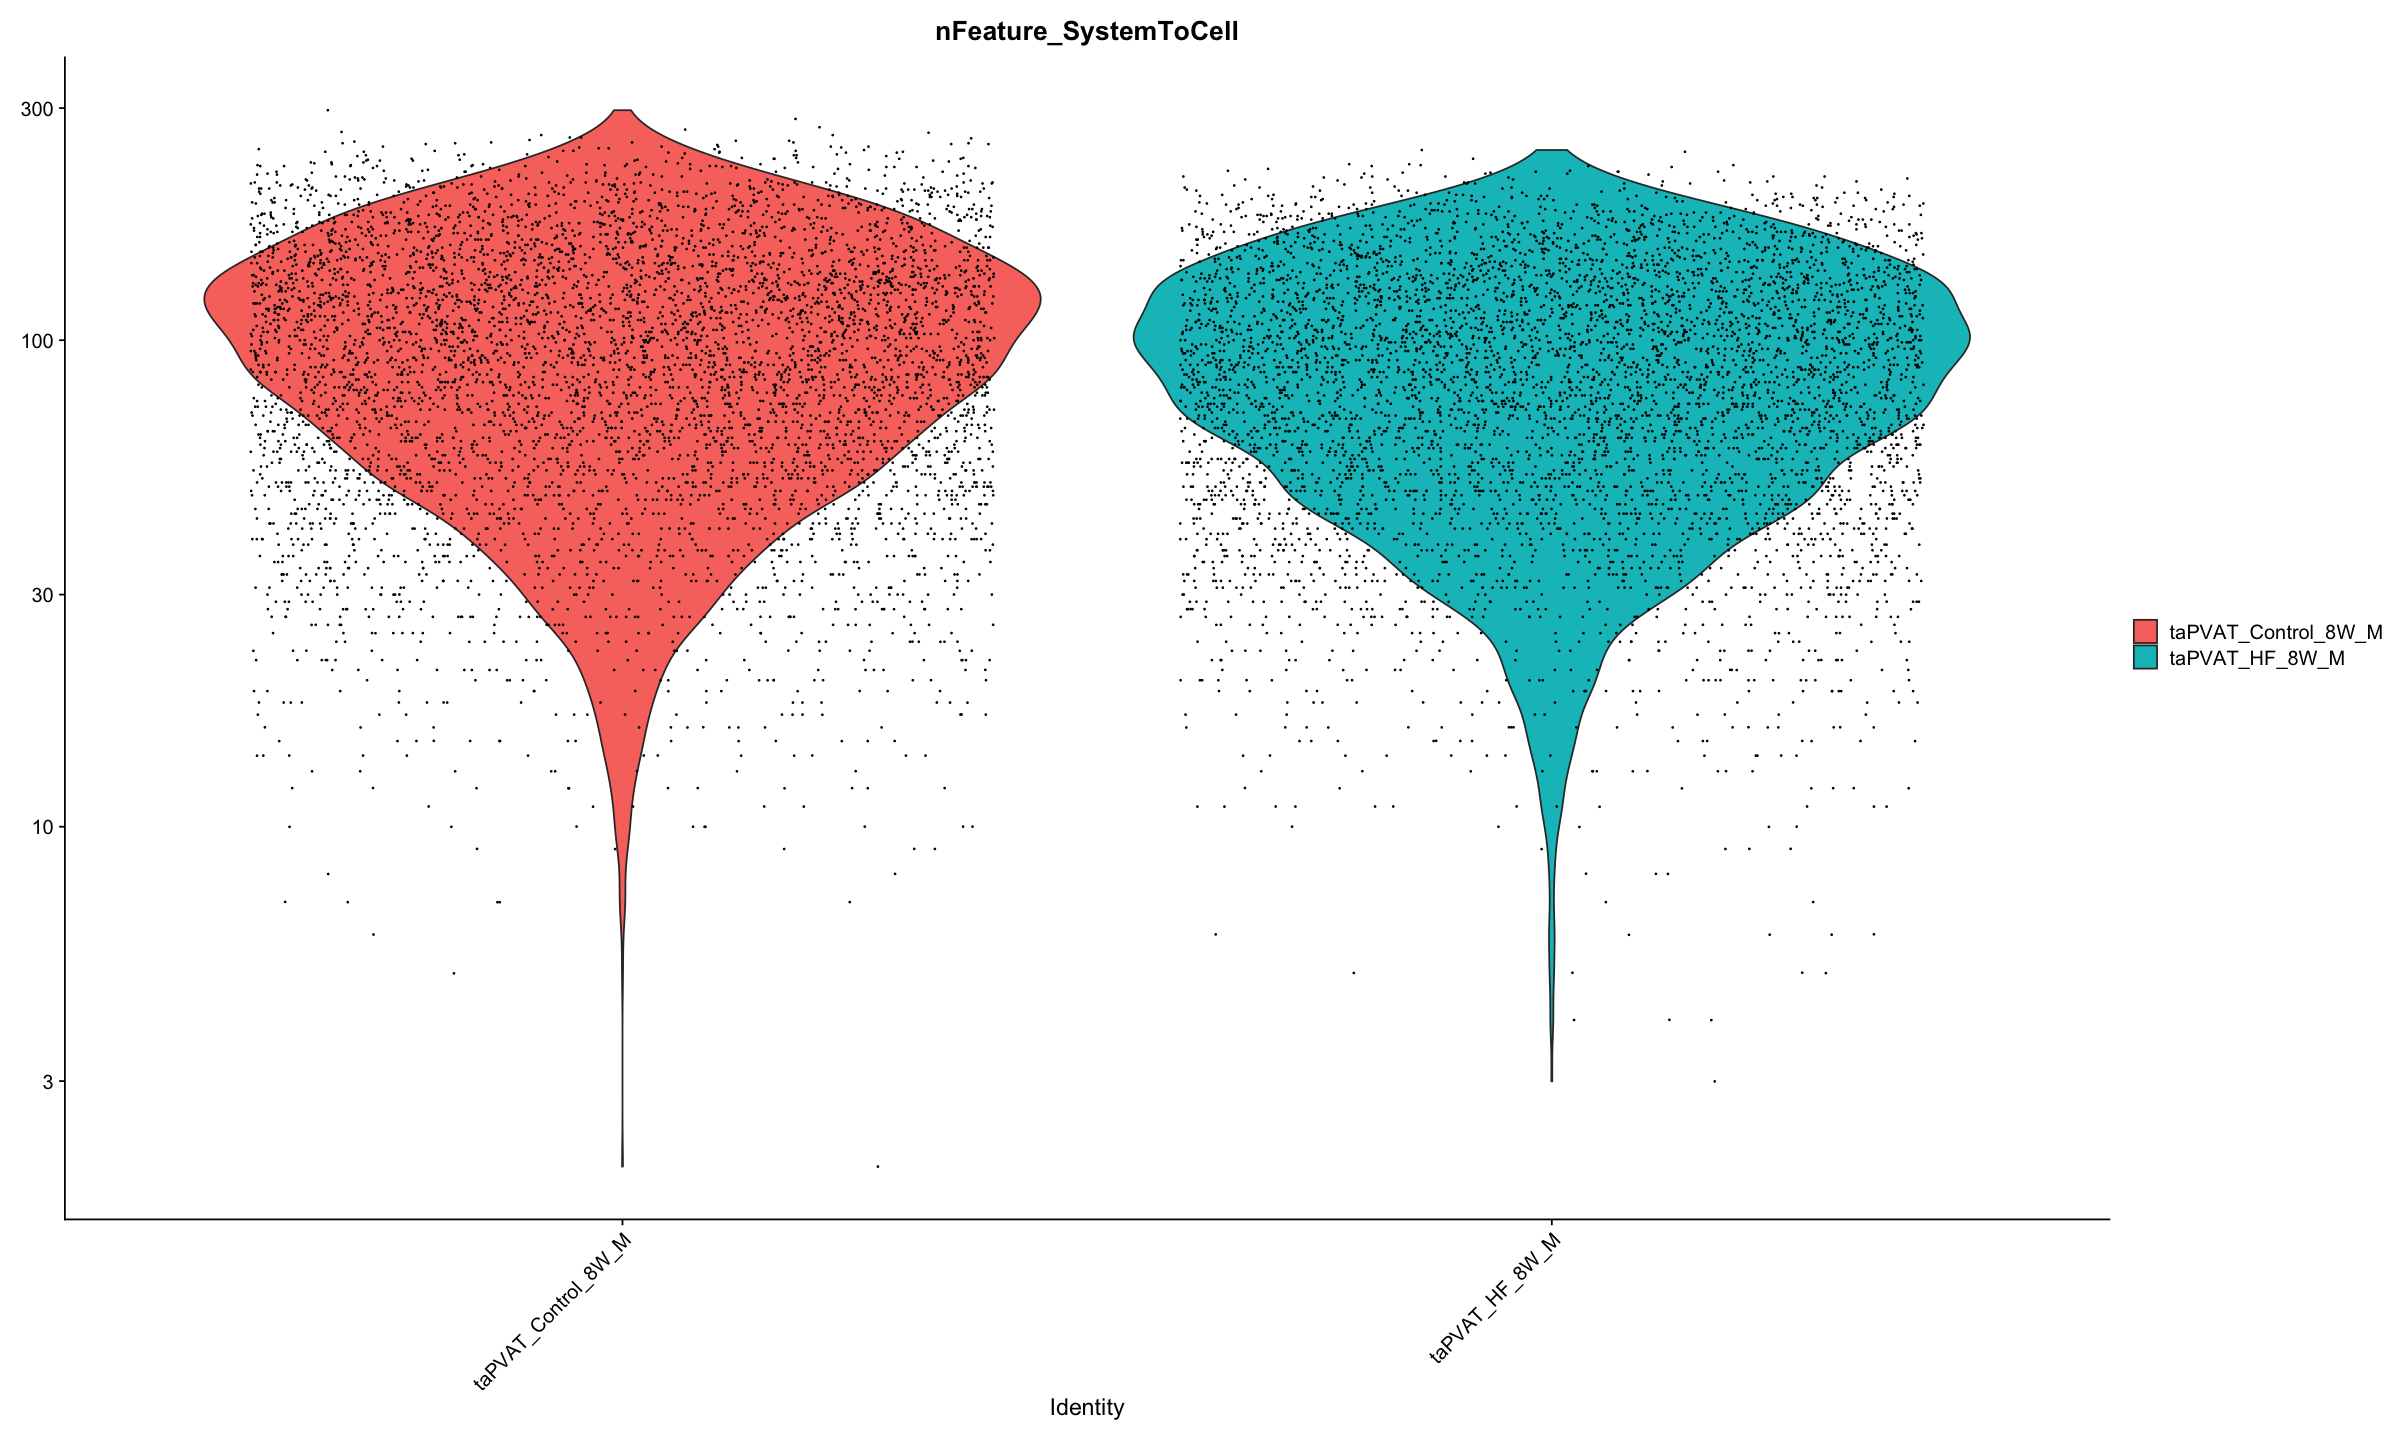

In [20]:
# Merge together
scc.merge <- merge(temp.list[[1]],temp.list[2])

# Clean up low-information crosses (connectivity data can be very sparse)
VlnPlot(scc.merge,features = 'nFeature_SystemToCell',group.by = 'Condition',pt.size=0.1,log = T)

In [21]:
scc.sub <- subset(scc.merge,nFeature_SystemToCell > 5) # Requesting at least 5 distinct ligand-receptor interactions per measurement

Centering and scaling data matrix

Finding variable features for layer data.1

Finding variable features for layer data.2

PC_ 1 
Positive:  Tfpi—Lrp1, Calr—Lrp1, Serpine2—Lrp1, App—Lrp1, F8—Lrp1, Psap—Lrp1, Hsp90b1—Lrp1, Lpl—Lrp1, Plat—Lrp1, Lrpap1—Lrp1 
	   Serping1—Lrp1, Pdgfb—Lrp1, Apoe—Lrp1, Ntf3—Ntrk3, Ptn—Ptprs, Hspg2—Ptprs, Gnas—Adrb3, Nrg2—Erbb4, Rtn4—Cntnap1, Tbc1d24—Cdon 
	   Adam17—Erbb4, Nrg4—Erbb4, Calr—Tshr, Egf—Erbb4, Gnas—Tshr, Fn1—Tshr, B2m—Tfrc, Gnai2—Tshr, Lrpap1—Sorl1, Nrg1—Erbb4 
Negative:  Col1a1—Itgb1, Lama2—Itgb1, Lamc1—Itgb1, Col6a2—Itgb1, Lamb1—Itgb1, Vtn—Itgb1, Nid1—Itgb1, Adam9—Itgb1, Adam12—Itgb1, Col6a1—Itgb1 
	   Fbn1—Itgb1, Cxcl12—Itgb1, Fn1—Itgb1, Col5a2—Itgb1, Col6a3—Itgb1, Col4a1—Itgb1, Fbln1—Itgb1, Timp2—Itgb1, Col1a2—Itgb1, Col18a1—Itgb1 
	   Hspg2—Itgb1, Adam15—Itgb1, Lama5—Itgb1, Col3a1—Itgb1, Col4a4—Itgb1, Reln—Itgb1, Npnt—Itgb1, Col4a5—Itgb1, Tgm2—Itgb1, Vcan—Itgb1 
PC_ 2 
Positive:  Ntf3—Ntrk3, Dkk2—Lrp6, Rspo3—Lrp6, Igfbp4—Lrp6, Rspo1—Lrp6, F

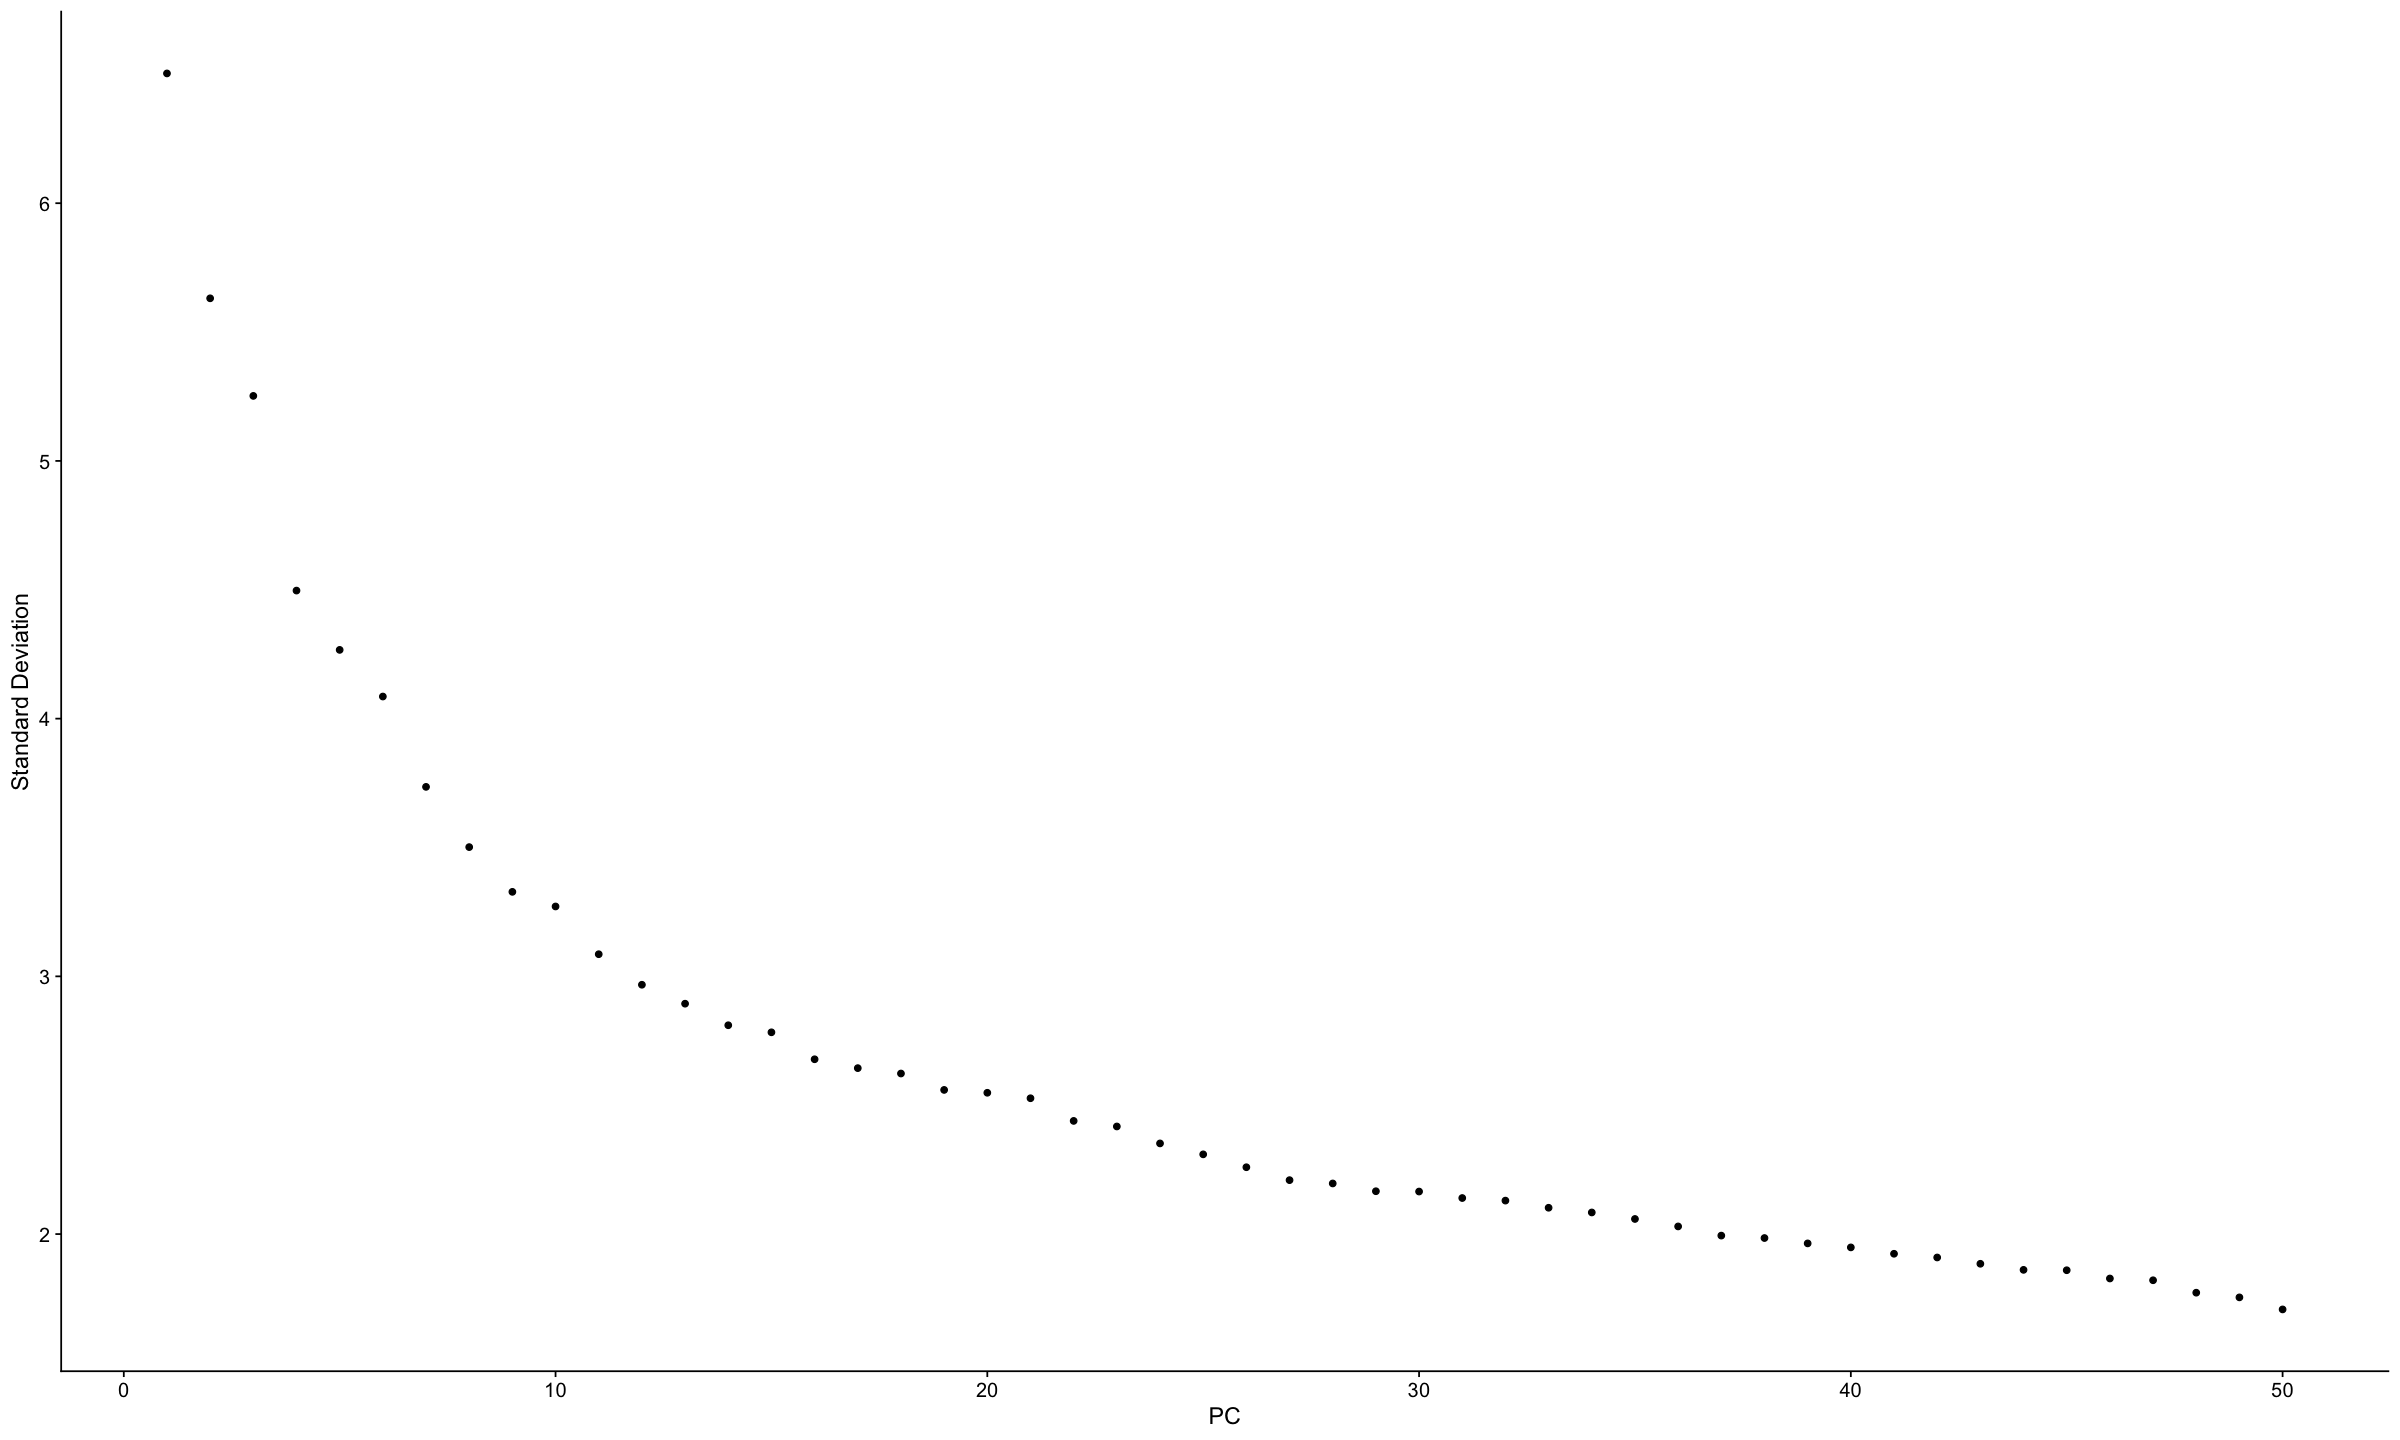

In [22]:
# Perform initial visualization
scc.sub <- ScaleData(scc.sub)
scc.sub <- FindVariableFeatures(scc.sub,selection.method = "disp")
scc.sub <- RunPCA(scc.sub,npcs = 50)
ElbowPlot(scc.sub,ndim=50)

14:38:38 UMAP embedding parameters a = 0.9922 b = 1.112

14:38:38 Read 11670 rows and found 10 numeric columns

14:38:38 Using Annoy for neighbor search, n_neighbors = 30

14:38:38 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:38:39 Writing NN index file to temp file /var/folders/kk/5gbzbkc93xb_g56p3bt9t8gh0000gp/T//RtmpzJ6iDU/file105518835490

14:38:39 Searching Annoy index using 1 thread, search_k = 3000

14:38:43 Annoy recall = 100%

14:38:43 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

14:38:44 Initializing from normalized Laplacian + noise (using RSpectra)

14:38:44 Commencing optimization for 200 epochs, with 457716 positive edges

14:38:54 Optimization finished



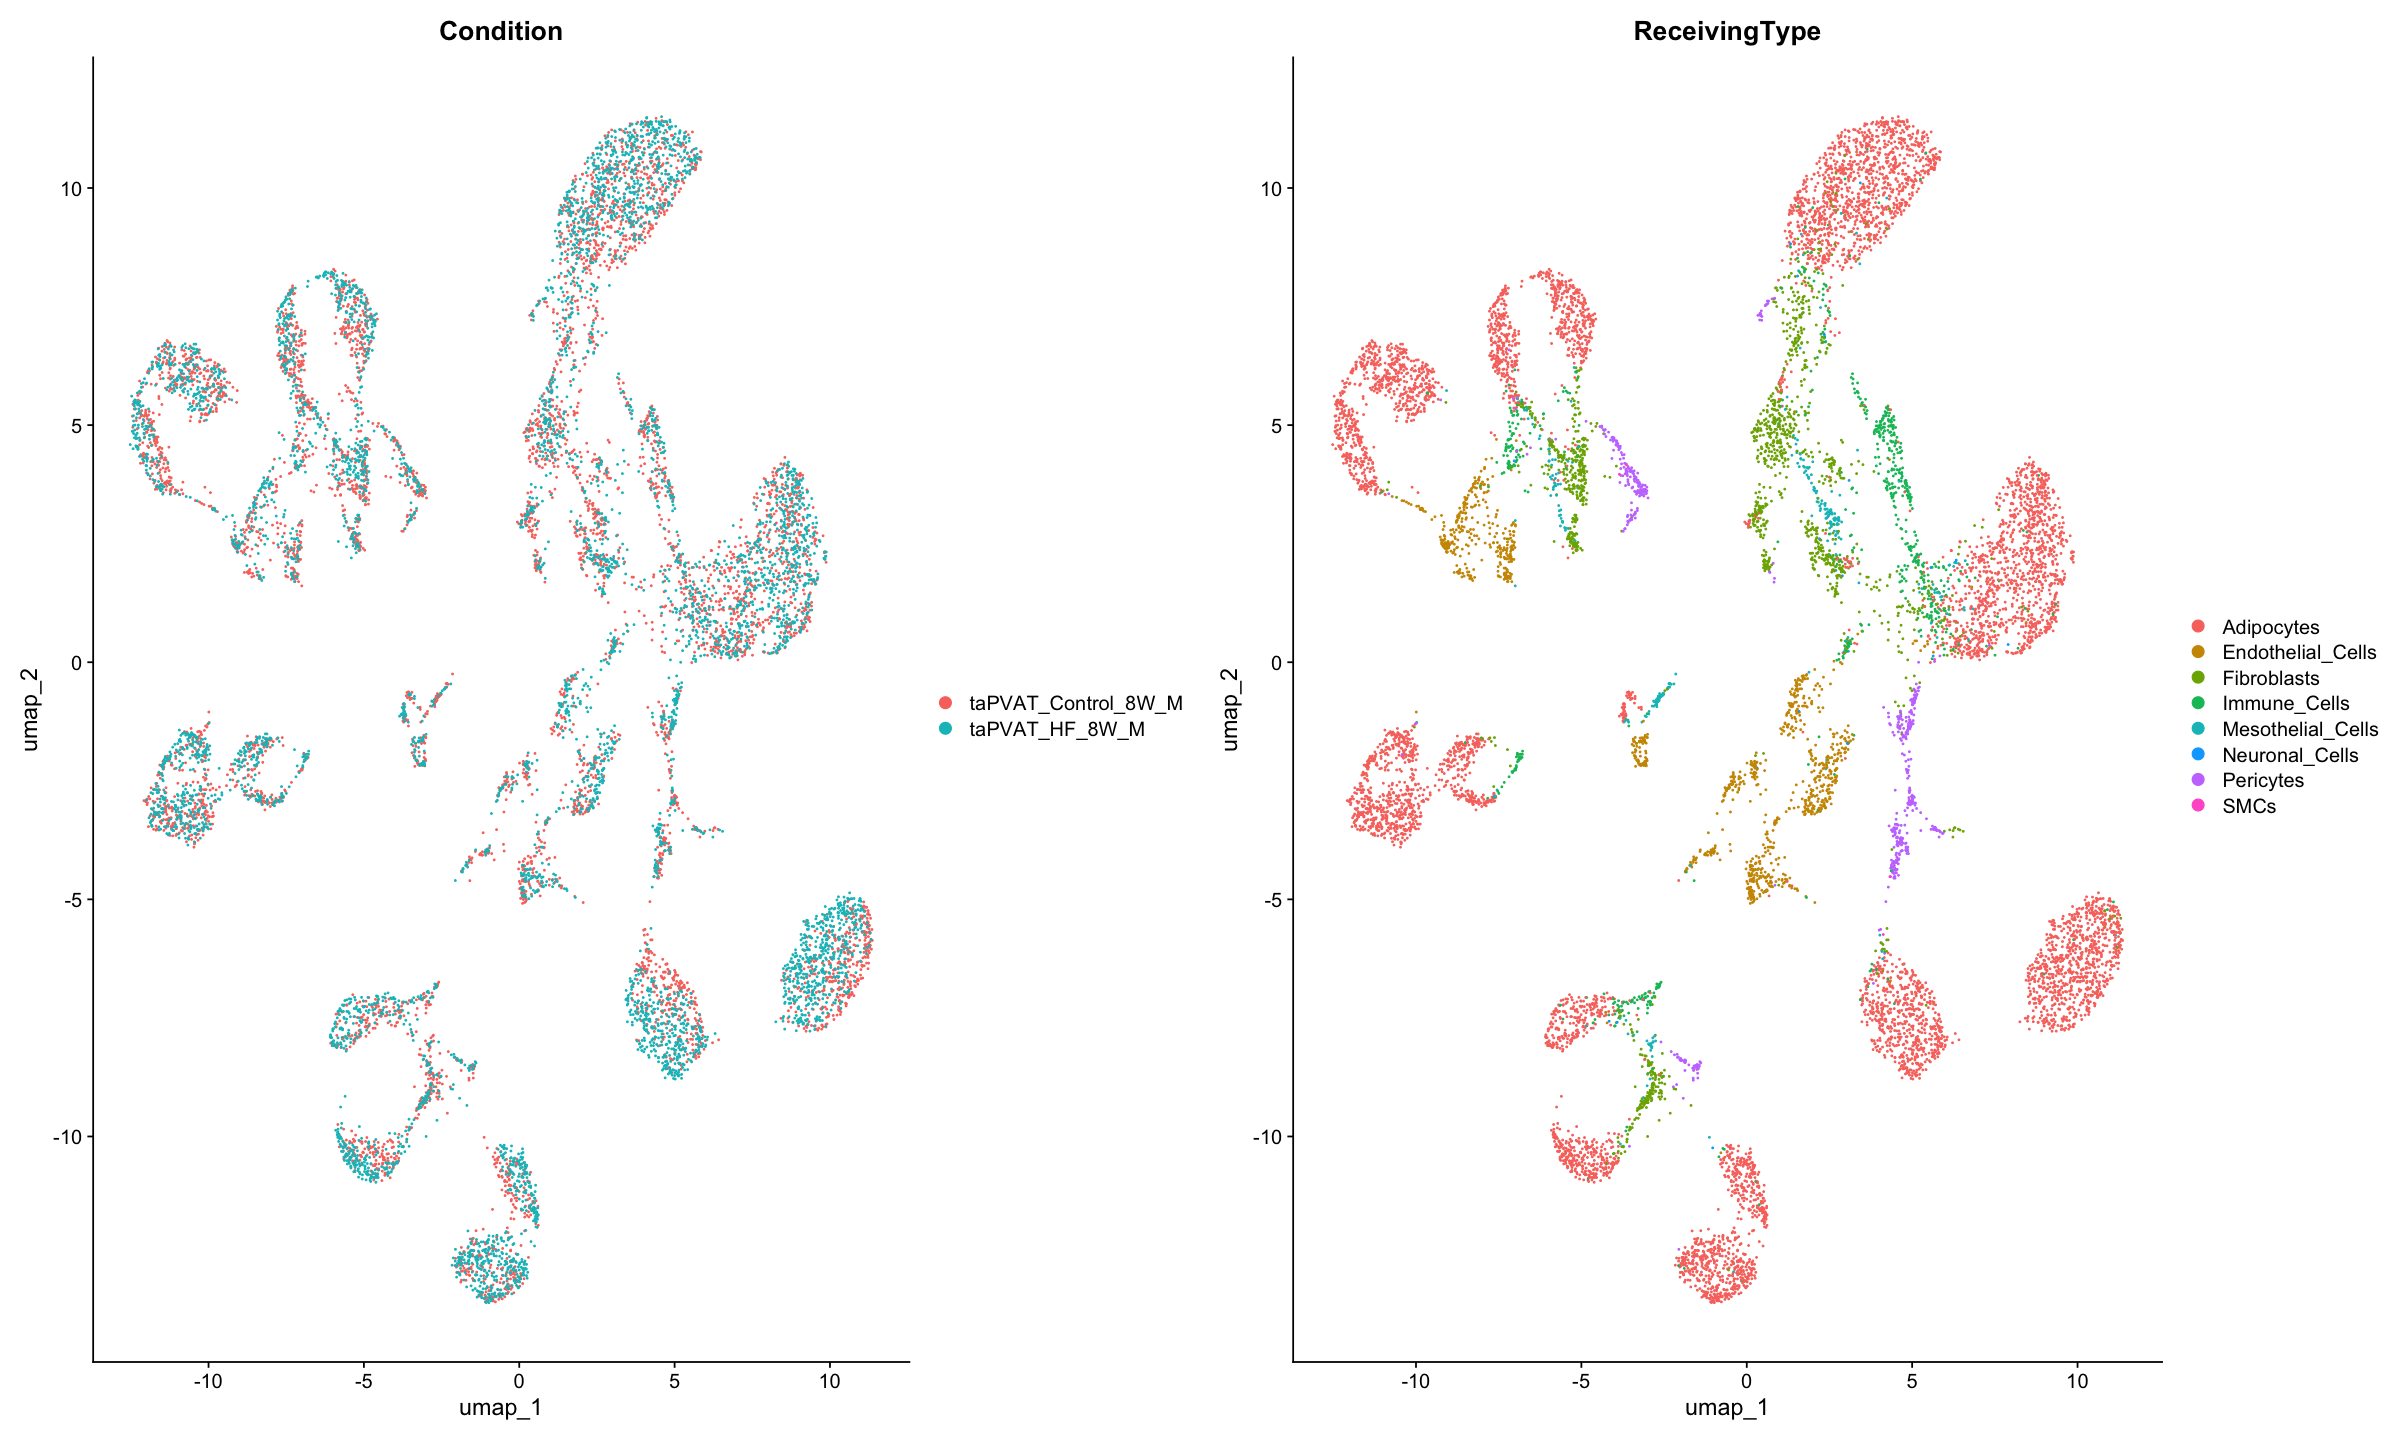

In [23]:
scc.sub <- RunUMAP(scc.sub,dims = 1:10)
p1 <- DimPlot(scc.sub,group.by = 'Condition')
p2 <- DimPlot(scc.sub,group.by = 'ReceivingType')
plot_grid(p1,p2)

In [24]:
unique(scc.sub@meta.data$ReceivingType)
COI <- "Adipocytes"

[1] "Fibroblasts"       "Adipocytes"        "Immune_Cells"     
[4] "Endothelial_Cells" "Pericytes"         "Mesothelial_Cells"
[7] "Neuronal_Cells"    "SMCs"

In [25]:
#saveRDS(scc.list, 'System2Cell.rds')

In [26]:
results <- lapply(COI, function(x){
 
  subs <- subset(scc.sub, subset = ReceivingType == x)

  subs <- JoinLayers(subs, layers = c("data", "scale.data"))
  
  print(paste0(x , ":  taPVAT_Control_8W_M:", sum(subs@meta.data$Condition == "taPVAT_Control_8W_M")))
  print(paste0(x , ":  taPVAT_HF_8W_M:", sum(subs@meta.data$Condition == "taPVAT_HF_8W_M")))
  
  Idents(subs) <- subs@meta.data$Condition
  
  FindVariableFeatures(subs,assay='SystemToCell',selection.method = "disp")
  ScaleData(subs, assay='SystemToCell')
  
  markers <- FindAllMarkers(subs, test.use = "roc",assay='SystemToCell',
                            min.pct = 0.1,logfc.threshold = 0.1,
                            return.thresh = 0.1,only.pos = T)
  print(markers)
  
  #subset to top 10 markers per condition
  top10 <- markers %>% group_by(cluster) %>% top_n(n = 10, wt = myAUC)
  list(subs = subs, top10 = top10)
  
  #Make a heatmap
  #DoHeatmap(subs,group.by="ident",features=top10$gene, assay="SystemToCell") +  ggtitle("Top DE SystemToCell Mechanisms, CTRL vs STIM: ",x)
 
  
})

options(repr.plot.width=20, repr.plot.height=12)
options(warn=-1)

subs <- results[[1]]$subs
top10 <- results[[1]]$top10

[1] "Adipocytes:  taPVAT_Control_8W_M:3545"
[1] "Adipocytes:  taPVAT_HF_8W_M:3913"


Finding variable features for layer data

Centering and scaling data matrix

Calculating cluster taPVAT_Control_8W_M

Calculating cluster taPVAT_HF_8W_M



                 myAUC     avg_diff power avg_log2FC pct.1 pct.2
Fgf2—Nrp1        0.859 0.0317658793 0.718  6.9932103 0.718 0.000
Rspo1—Lrp6       0.812 0.0379716749 0.624  0.6946588 0.850 0.904
Igfbp4—Lrp6      0.804 0.1134582596 0.608  0.7229966 0.850 0.904
Tgfb3—Tgfbr3     0.802 0.0386900791 0.604  7.2804456 0.604 0.000
Serpinc1—Lrp1    0.781 0.0156774919 0.562  5.9757501 0.561 0.000
Rspo3—Lrp6       0.775 0.0201427095 0.550  0.5031797 0.850 0.904
Cntn4—Ptprg      0.758 0.0254834604 0.516  6.6738675 0.517 0.000
Sema7a—Itga1     0.729 0.0149069067 0.458  5.9037967 0.458 0.000
Col4a6—Itga1     0.729 0.0198290349 0.458  6.3123241 0.458 0.000
Sema3e—Nrp1      0.717 0.0336790185 0.434  0.7751663 0.718 0.783
Fgf2—Fgfr1       0.716 0.0137477257 0.432  5.7884283 0.432 0.000
Tgfb3—Tgfbr2     0.706 0.0232362559 0.412  6.5405832 0.413 0.000
Bmp5—Bmpr2       0.706 0.0229886542 0.412  6.5251347 0.413 0.000
Dkk2—Lrp6        0.702 0.0300930302 0.404  0.3180732 0.850 0.904
Sema3a—Nrp1      0.683 0.

# System to Cell 

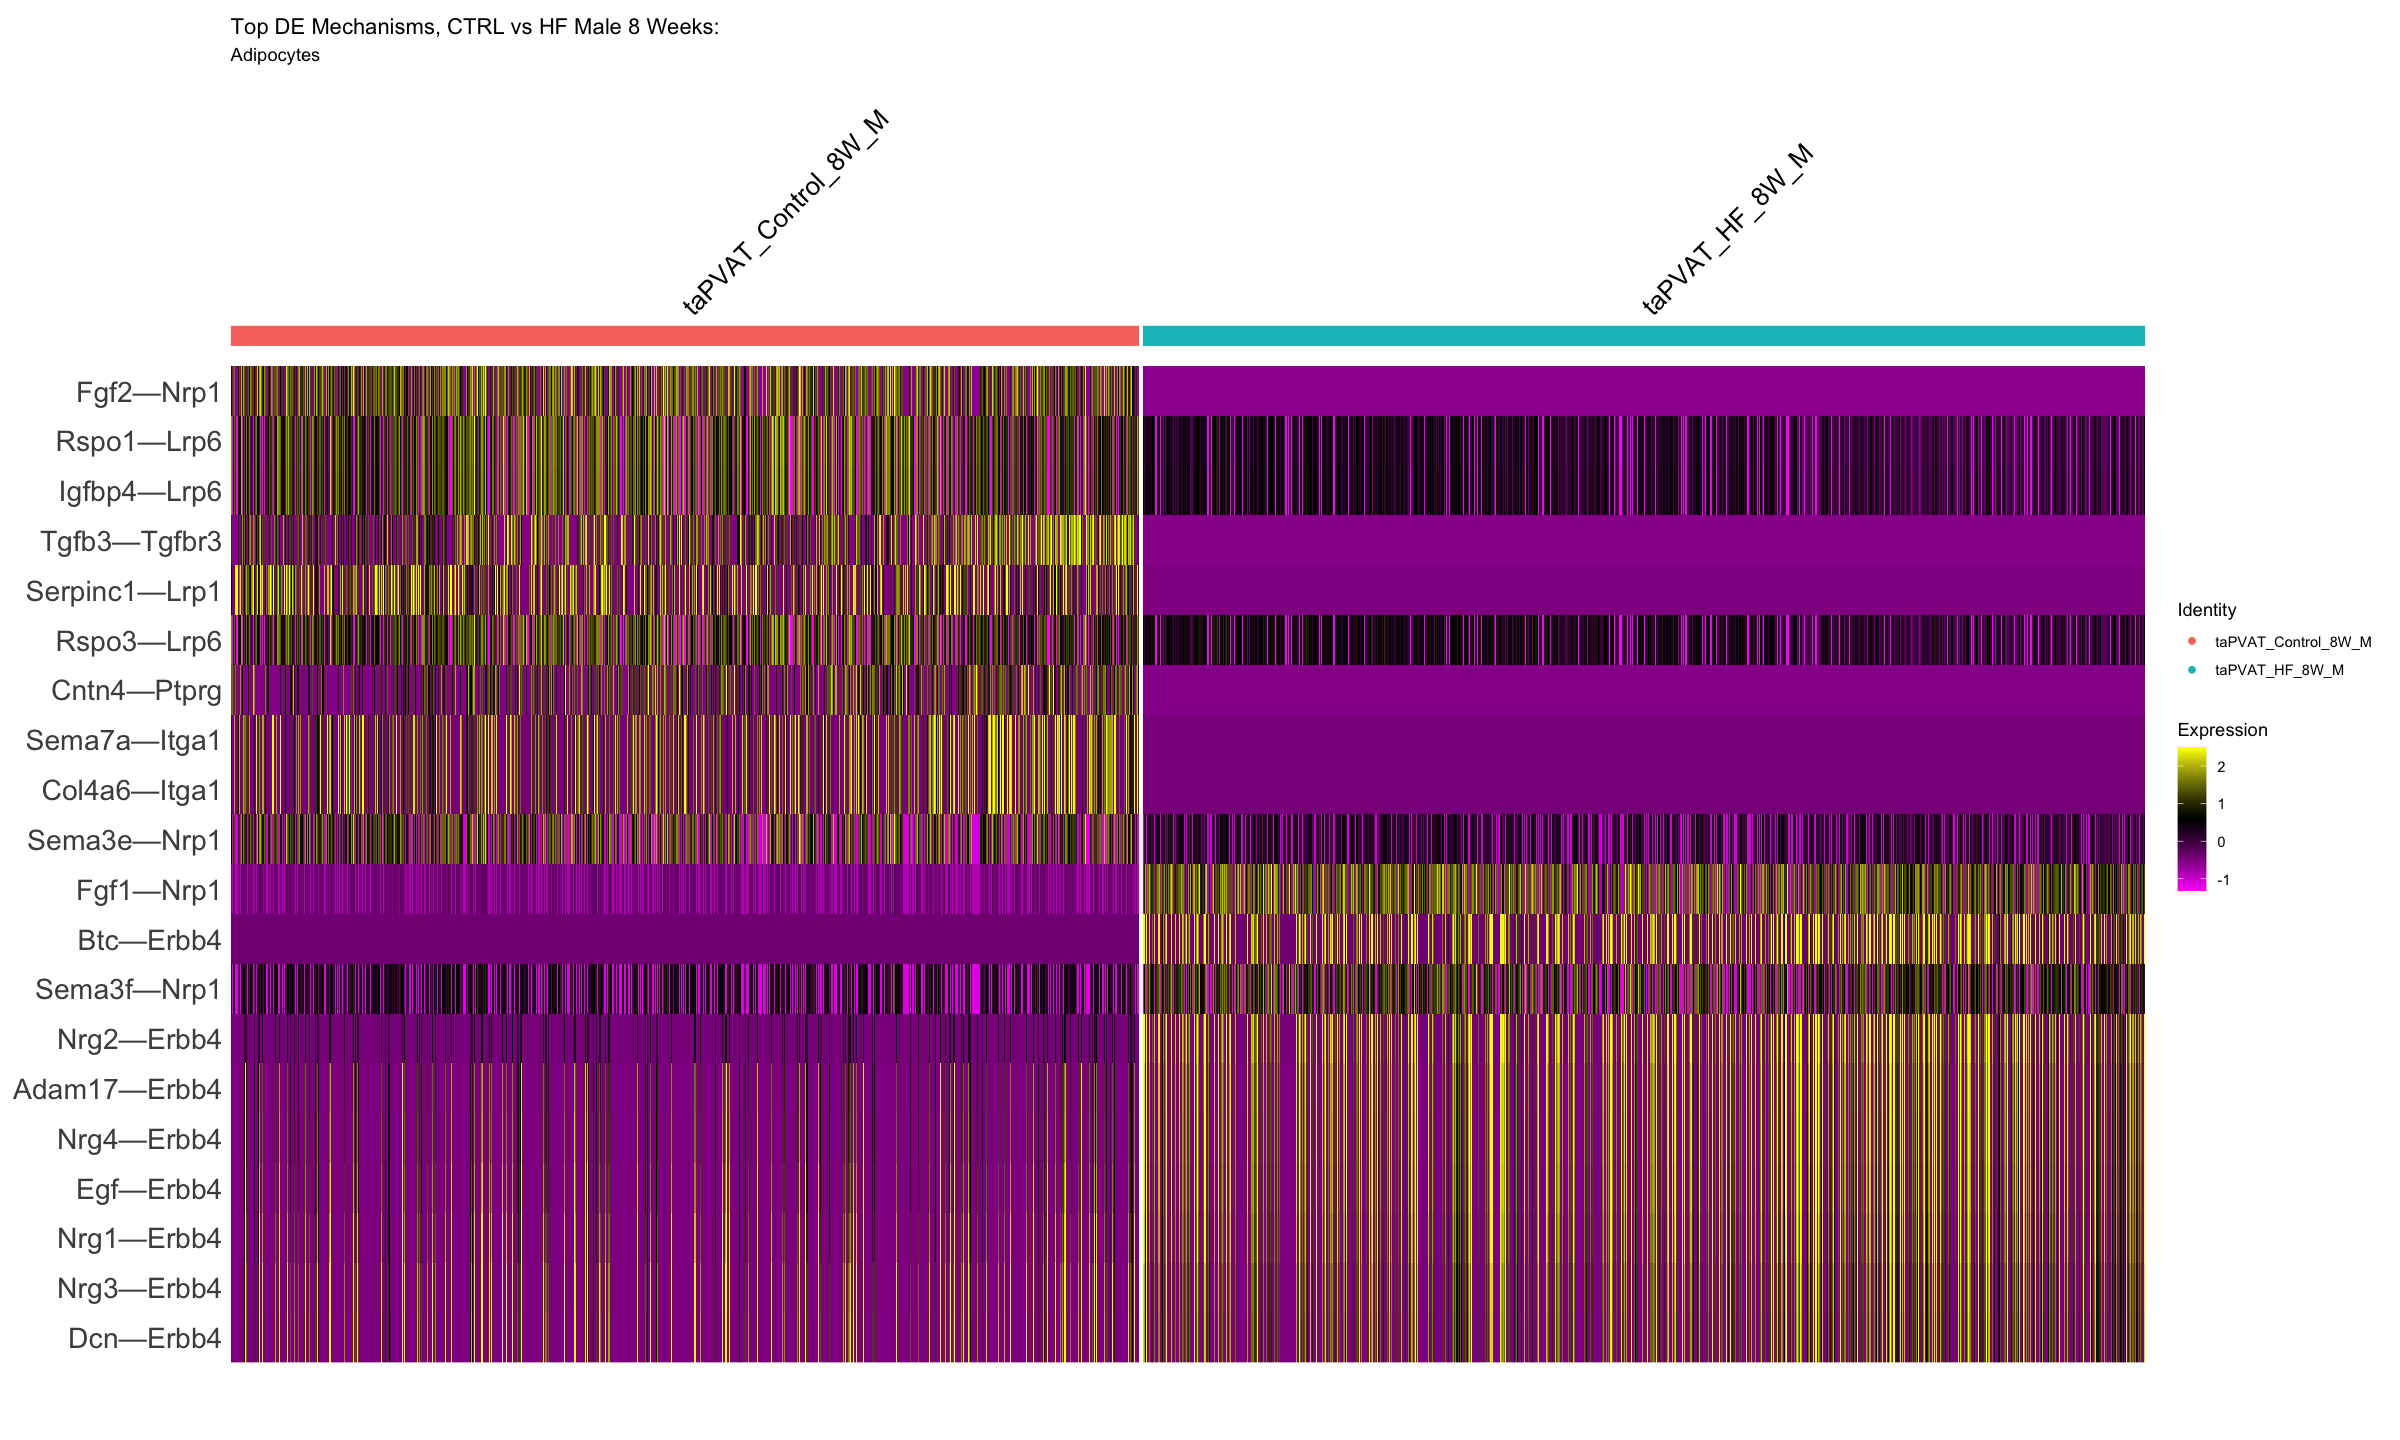

In [32]:
DoHeatmap(subs,group.by="ident",features=top10$gene, assay="SystemToCell") +  ggtitle("Top Interaction Mechanisms, CTRL vs HF Male 8 Weeks: ",COI) + theme(#axis.text.x = element_text(face = "italic", size = 20),
                                                                   axis.text.y = element_text(size = 17))
                                                                   #axis.title.x = element_text(size = 20),
                                                                   #axis.title.y = element_text(size = 20),
                                                                   #plot.title = element_text(hjust = 0.5))

The default behaviour of split.by has changed.
Separate violin plots are now plotted side-by-side.
To restore the old behaviour of a single split violin,
set split.plot = TRUE.
      
This message will be shown once per session.



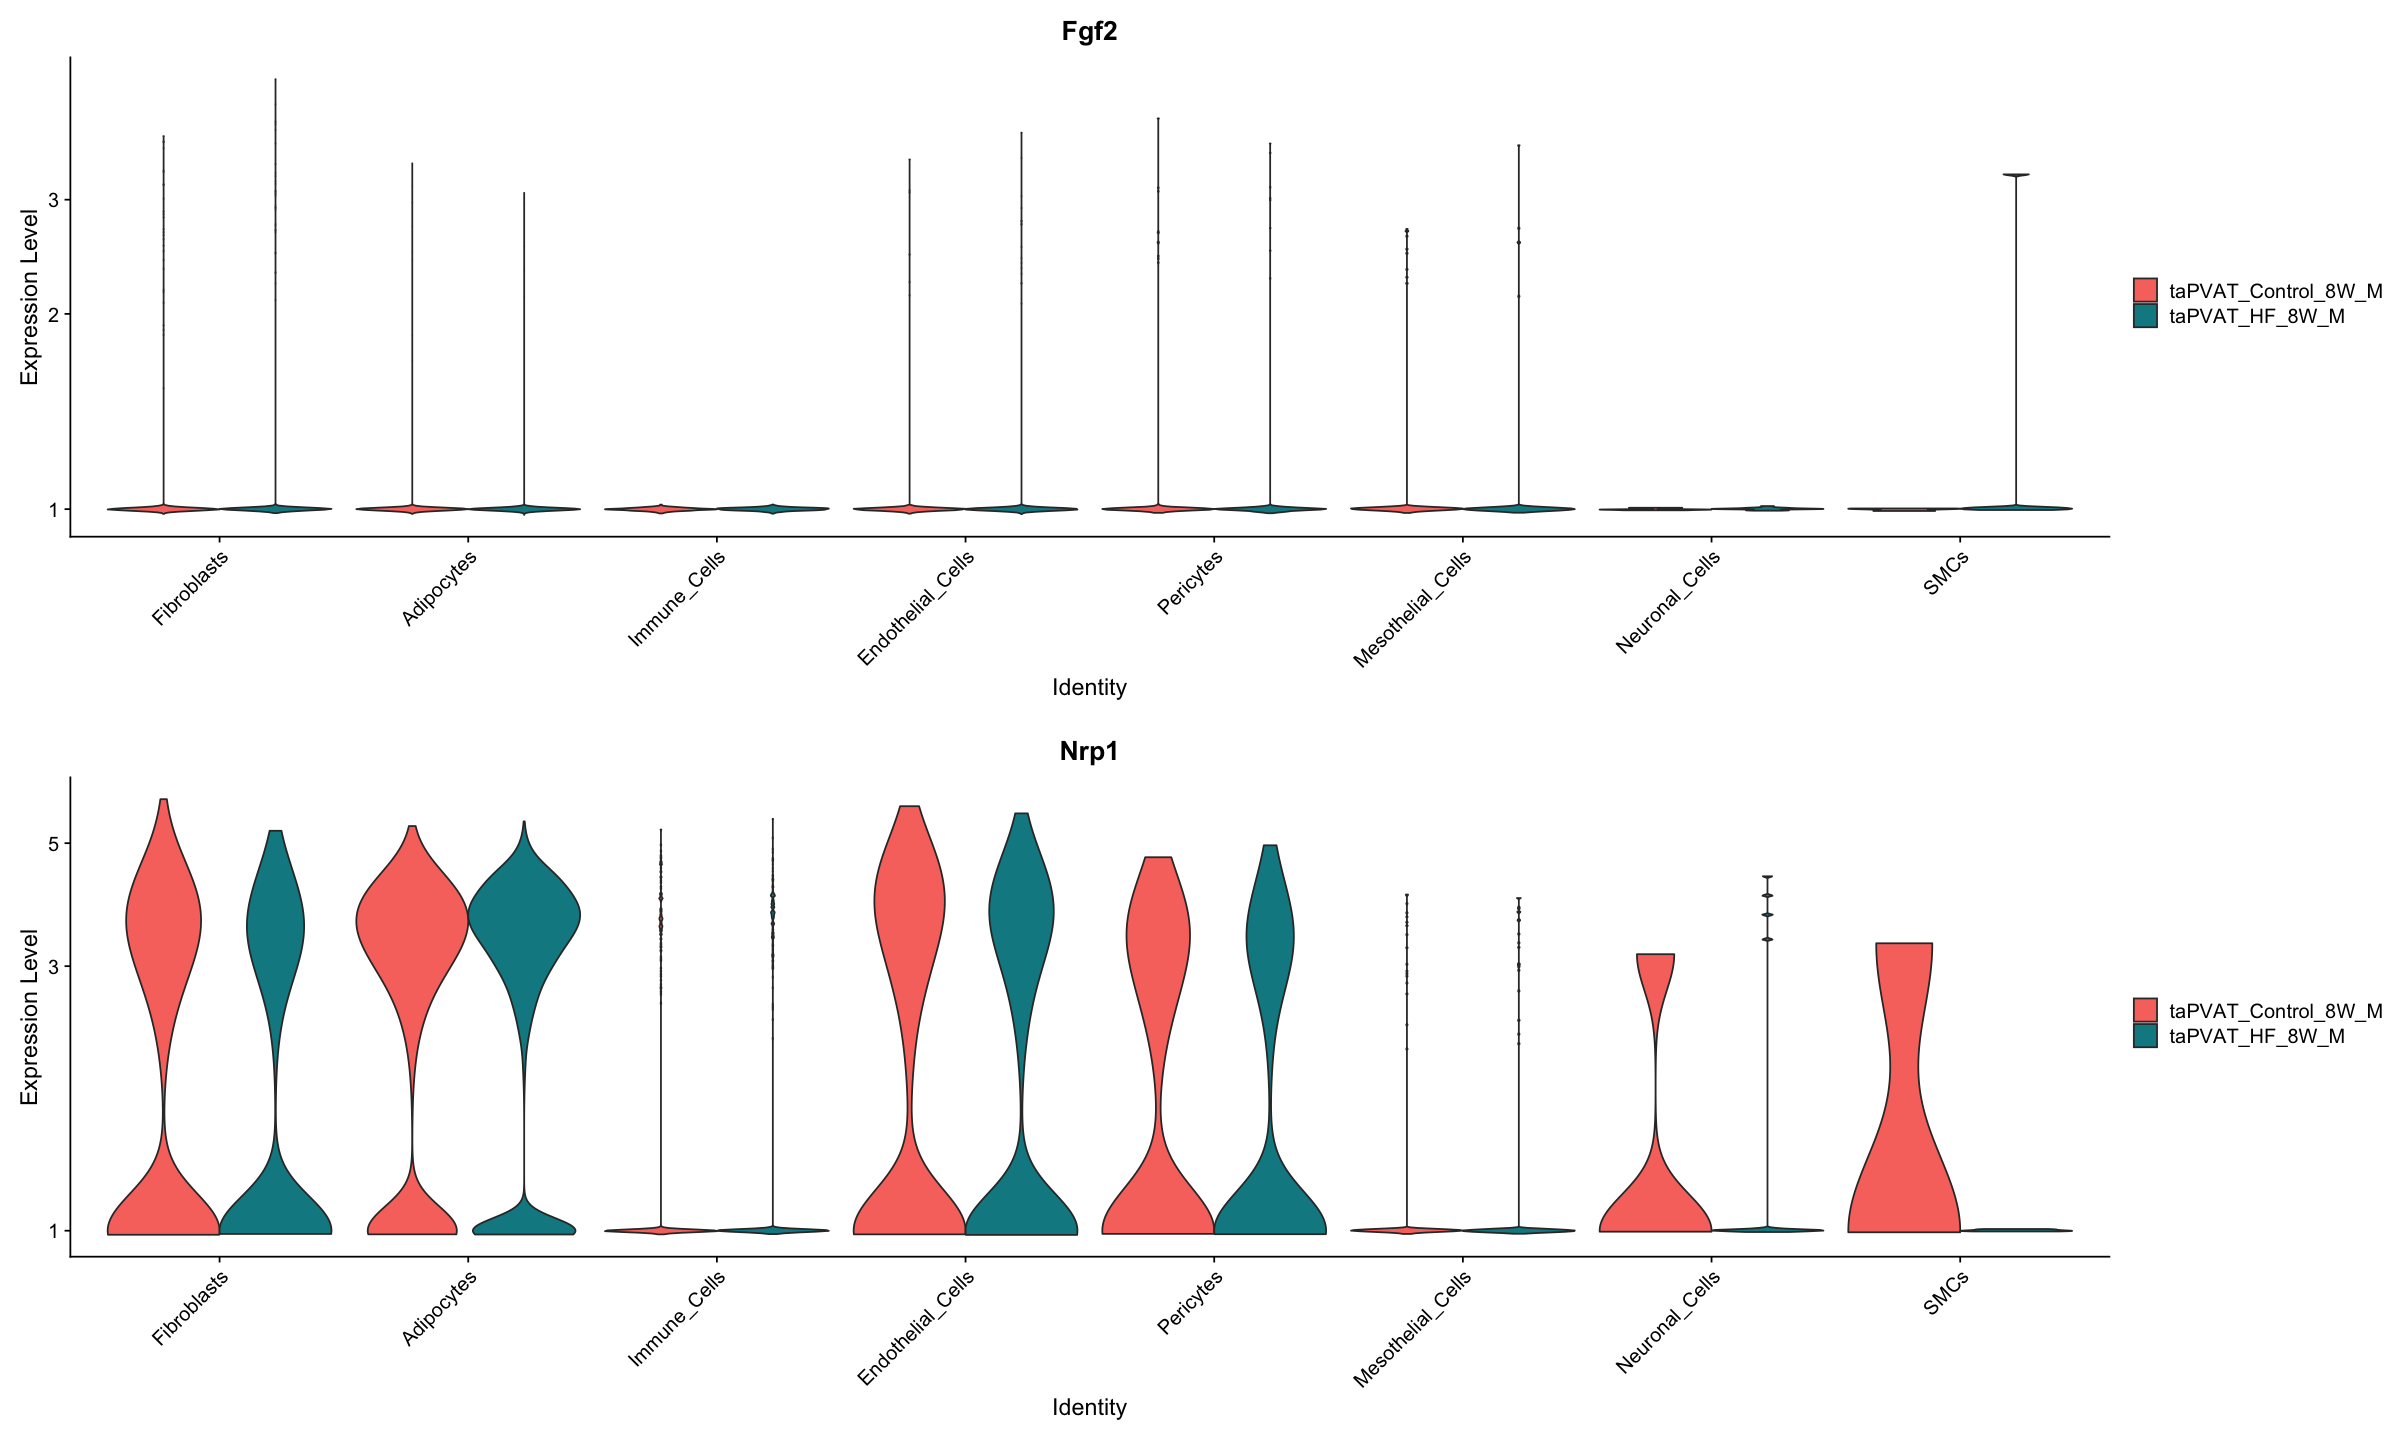

In [33]:
p1 <- VlnPlot(male_8weeks_rds,'Fgf2',split.by = 'sample_type',pt.size = 0,log=T)
p2 <- VlnPlot(male_8weeks_rds,'Nrp1',split.by = 'sample_type',pt.size = 0,log=T)
plot_grid(p1,p2,ncol=1)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Rspo1—Lrp6' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Rspo1—Lrp6' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Rspo1—Lrp6' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Rspo1—Lrp6' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Rspo1—Lrp6' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Rspo1—Lrp6' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_tex

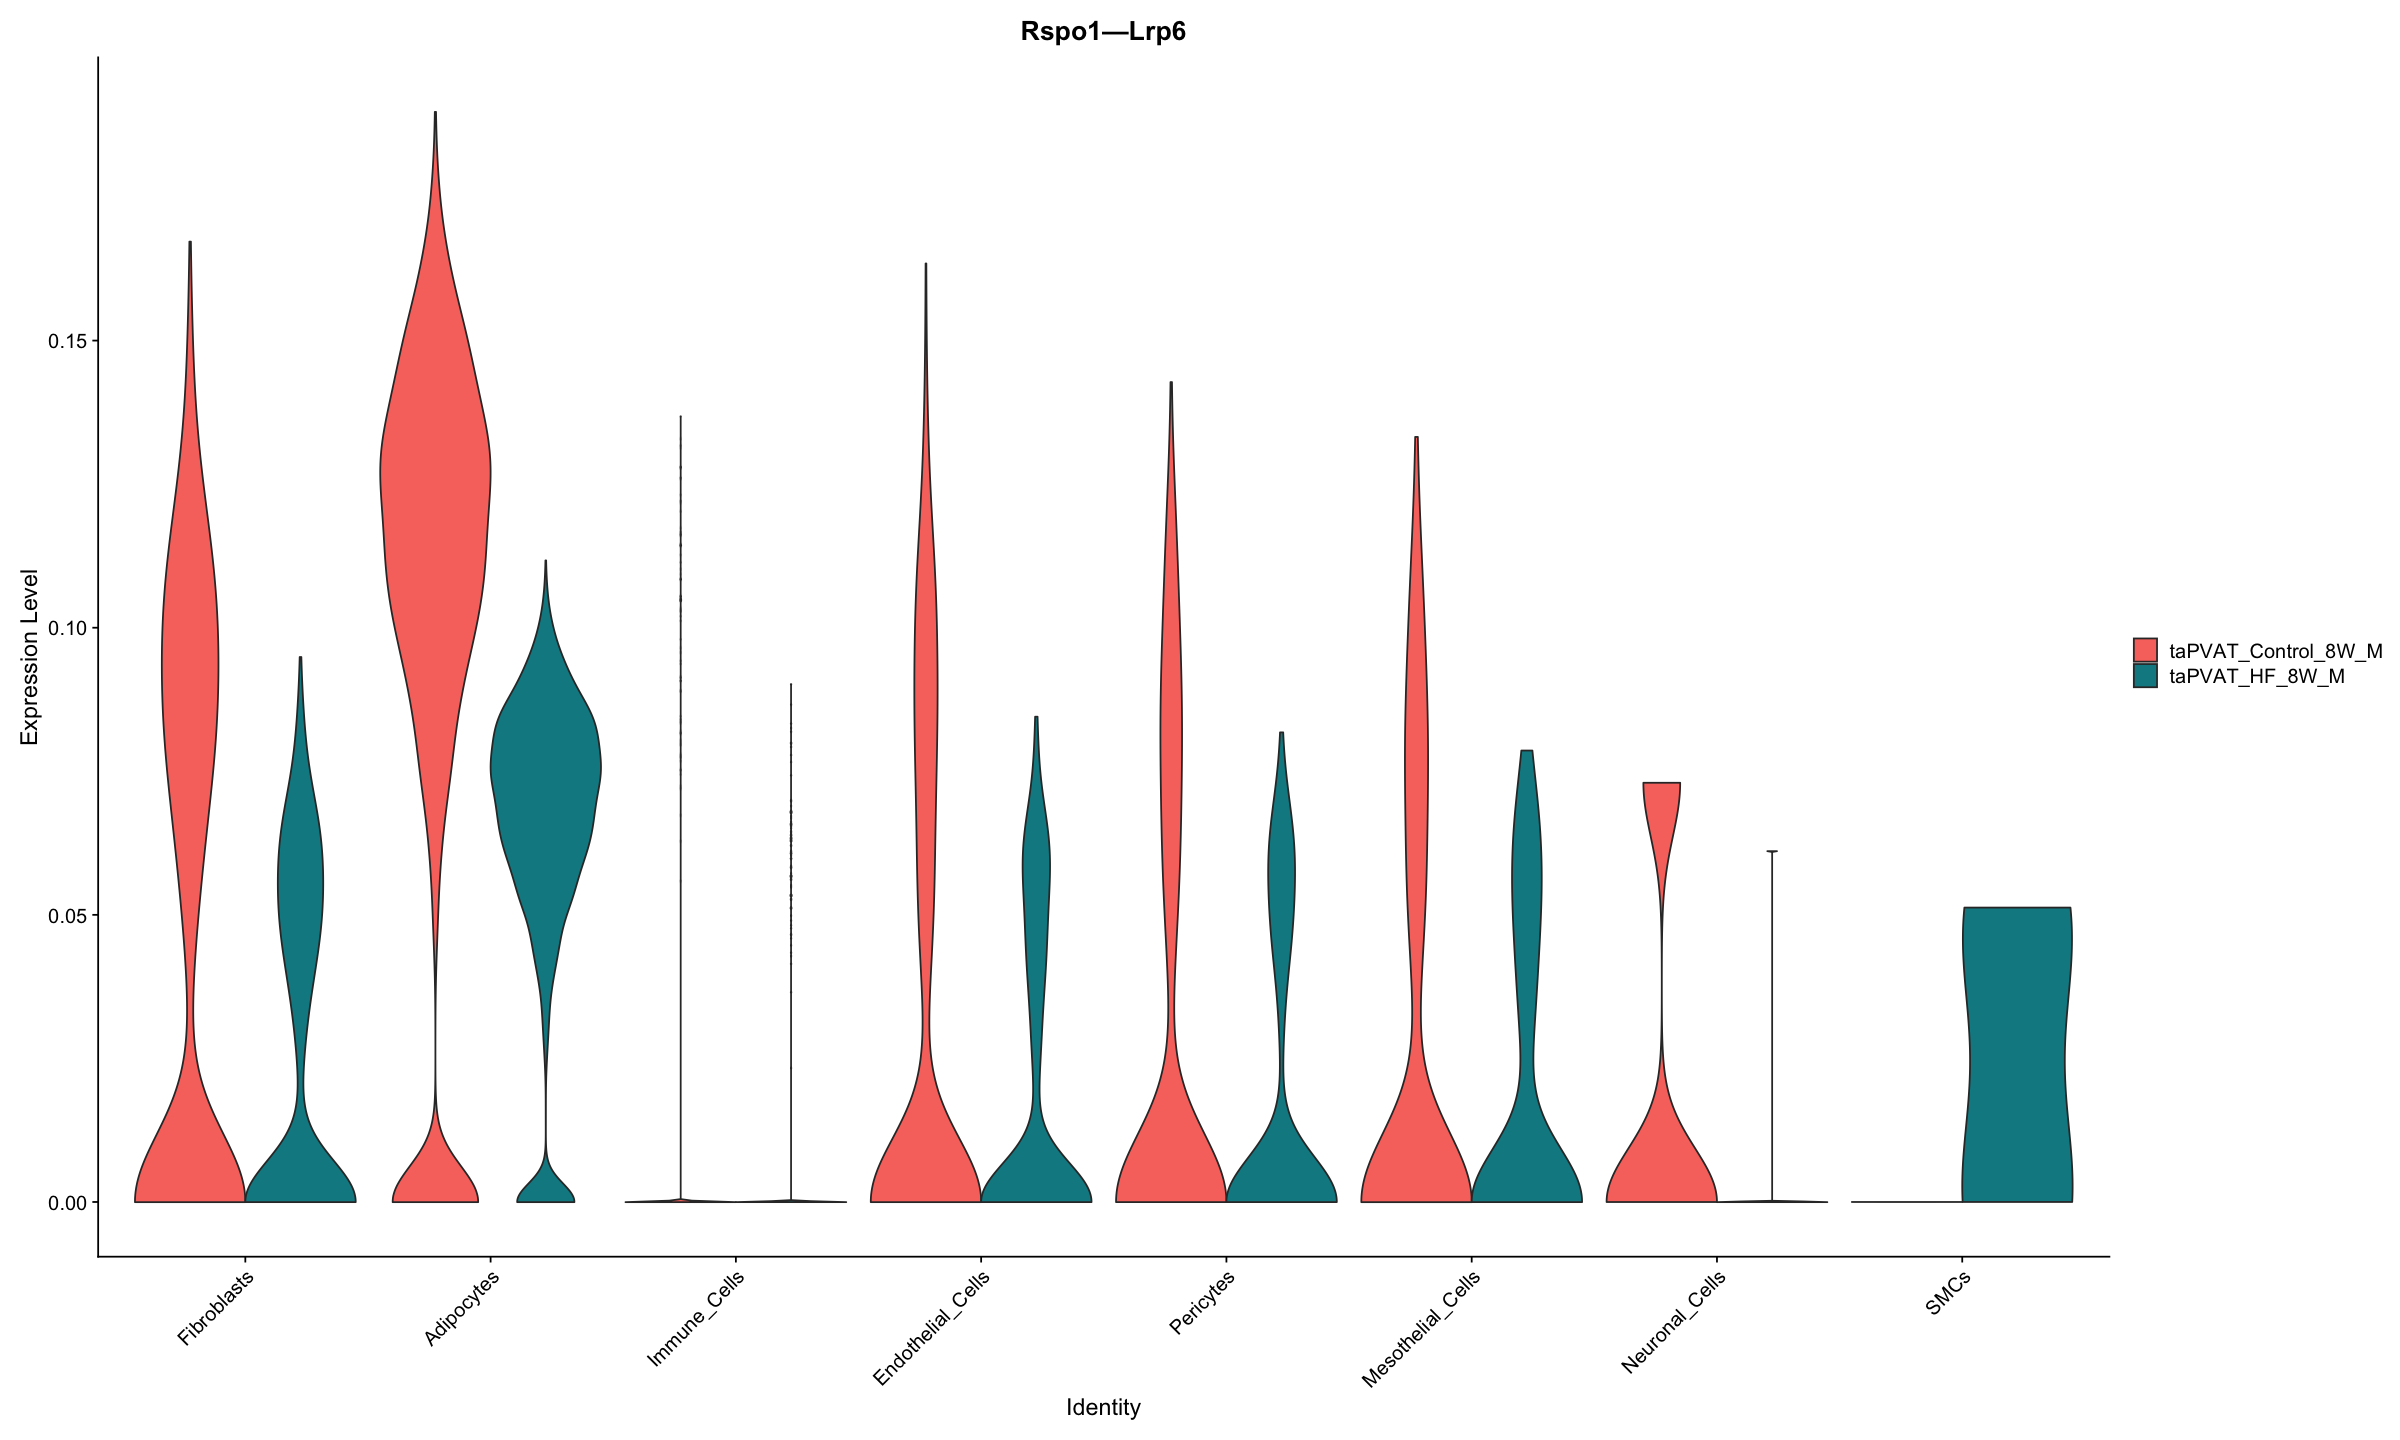

In [68]:
VlnPlot(scc.sub, 'Rspo1—Lrp6',split.by = 'Condition',pt.size = 0)

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
PC_ 1 
Positive:  Tfpi—Lrp1, Calr—Lrp1, Serpine2—Lrp1, App—Lrp1, F8—Lrp1, Psap—Lrp1, Hsp90b1—Lrp1, Lpl—Lrp1, Plat—Lrp1, Lrpap1—Lrp1 
	   Nxph1—Nrxn1, Serping1—Lrp1, Psen1—Notch1, Mfap5—Notch1, Dll1—Notch1, Uba52—Notch1, Dll4—Notch1, Adam17—Notch1, Jag1—Notch1, Jag2—Notch1 
	   Rarres2—Cmklr1, Pdgfb—Lrp1, Ptn—Ptprs, Calr—Tshr, Apoe—Lrp1, Gnas—Tshr, Fn1—Tshr, Hspg2—Ptprs, Gnai2—Tshr, Icam1—Egfr 
Negative:  Lama2—Itgb1, Col1a1—Itgb1, Lamc1—Itgb1, Nid1—Itgb1, Col6a2—Itgb1, Adam9—Itgb1, Lamb1—Itgb1, Vtn—Itgb1, Adam12—Itgb1, Fn1—Itgb1 
	   Col6a1—Itgb1, Fbn1—Itgb1, Col4a1—Itgb1, Cxcl12—Itgb1, Col5a2—Itgb1, Col6a3—Itgb1, Fbln1—Itgb1, Col18a1—Itgb1, Timp2—Itgb1, Col1a2—Itgb1 
	   Hspg2—Itgb1, Adam15—Itgb1, Lama5—Itgb1, Col3a1—Itgb1, Col4a4—Itgb1, Npnt—Itgb1, Reln—Itgb1, Tgm2—Itgb1, Vcan—Itgb1, Col4a5—Itgb1 
PC_ 2 
Positive:  Vegfc—Itgb1, Col4a5—Itgb1, Vcam1—Itgb1, Reln—

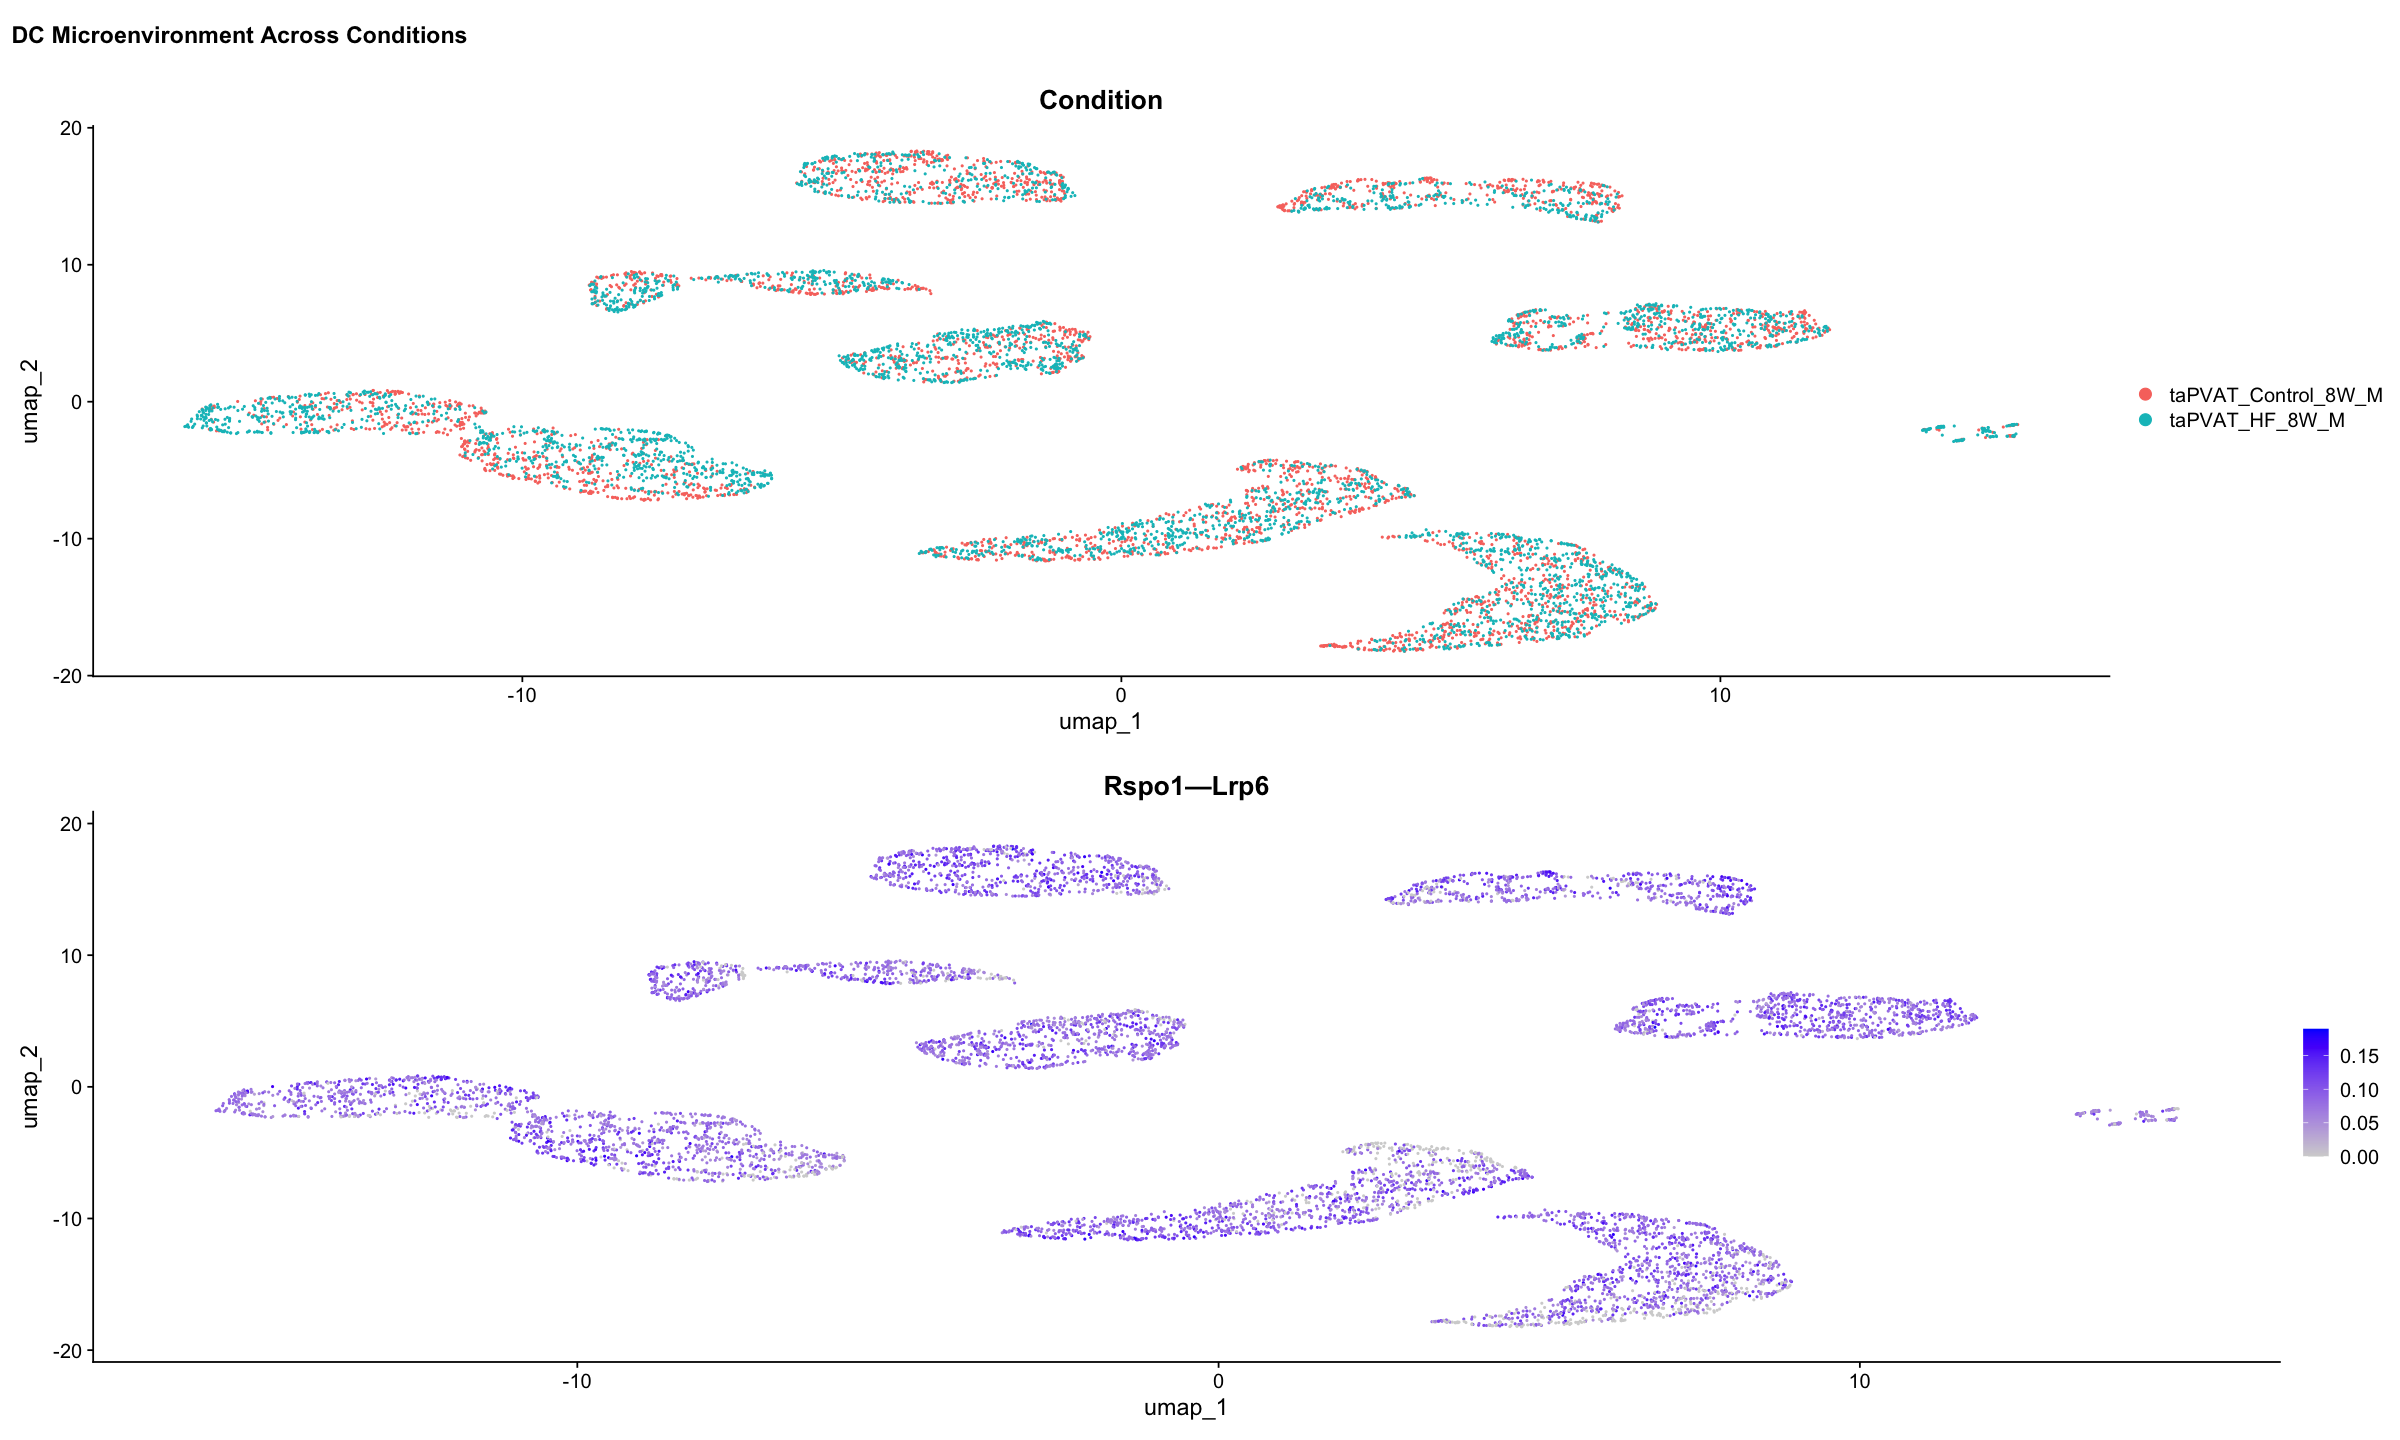

In [69]:
subs <- subset(scc.sub, idents = 'Adipocytes')
subs <- ScaleData(subs)
subs <- RunPCA(subs)
subs <- RunUMAP(subs,dims = 1:5)
p1 <- DimPlot(subs,group.by = 'Condition')
p2 <- FeaturePlot(subs,'Rspo1—Lrp6')
title <- ggdraw() + 
  draw_label(
    "DC Microenvironment Across Conditions",
    fontface = 'bold',
    x = 0,
    hjust = 0
  ) +
  theme(
    # add margin on the left of the drawing canvas,
    # so title is aligned with left edge of first plot
    plot.margin = margin(0, 0, 0, 7)
  )
plot_grid(title,p1,p2,ncol=1,rel_heights = c(0.1, 1,1))